In [5]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

In [2]:
# Đọc dữ liệu và loại bỏ các giá trị NA
data = pd.read_csv('Intel_CPUs_Cleaned_Final.csv')

# Tách dữ liệu thành 4 nhóm
desktop = data[data['Vertical_Segment'] == 'Desktop']['Recommended_Customer_Price']
mobile = data[data['Vertical_Segment'] == 'Mobile']['Recommended_Customer_Price']
embedded = data[data['Vertical_Segment'] == 'Embedded']['Recommended_Customer_Price']
server = data[data['Vertical_Segment'] == 'Server']['Recommended_Customer_Price']

In [3]:
# Hàm tính thống kê
def summary_stats(data):
    return len(data), data.mean(), data.std()

# Tính cho từng nhóm
stats_desktop = summary_stats(desktop)
stats_mobile = summary_stats(mobile)
stats_embedded = summary_stats(embedded)
stats_server = summary_stats(server)

# In bảng
print(f"{'Phân khúc':<12}{'n':<10}{'Mean (USD)':<15}{'Std (USD)'}")
print("-"*50)

print(f"{'Desktop':<12}{stats_desktop[0]:<10}{stats_desktop[1]:<15.2f}{stats_desktop[2]:.2f}")
print(f"{'Mobile':<12}{stats_mobile[0]:<10}{stats_mobile[1]:<15.2f}{stats_mobile[2]:.2f}")
print(f"{'Embedded':<12}{stats_embedded[0]:<10}{stats_embedded[1]:<15.2f}{stats_embedded[2]:.2f}")
print(f"{'Server':<12}{stats_server[0]:<10}{stats_server[1]:<15.2f}{stats_server[2]:.2f}")

Phân khúc   n         Mean (USD)     Std (USD)
--------------------------------------------------
Desktop     628       254.34         167.77
Mobile      760       290.86         107.21
Embedded    177       423.37         574.74
Server      718       1321.15        1780.57


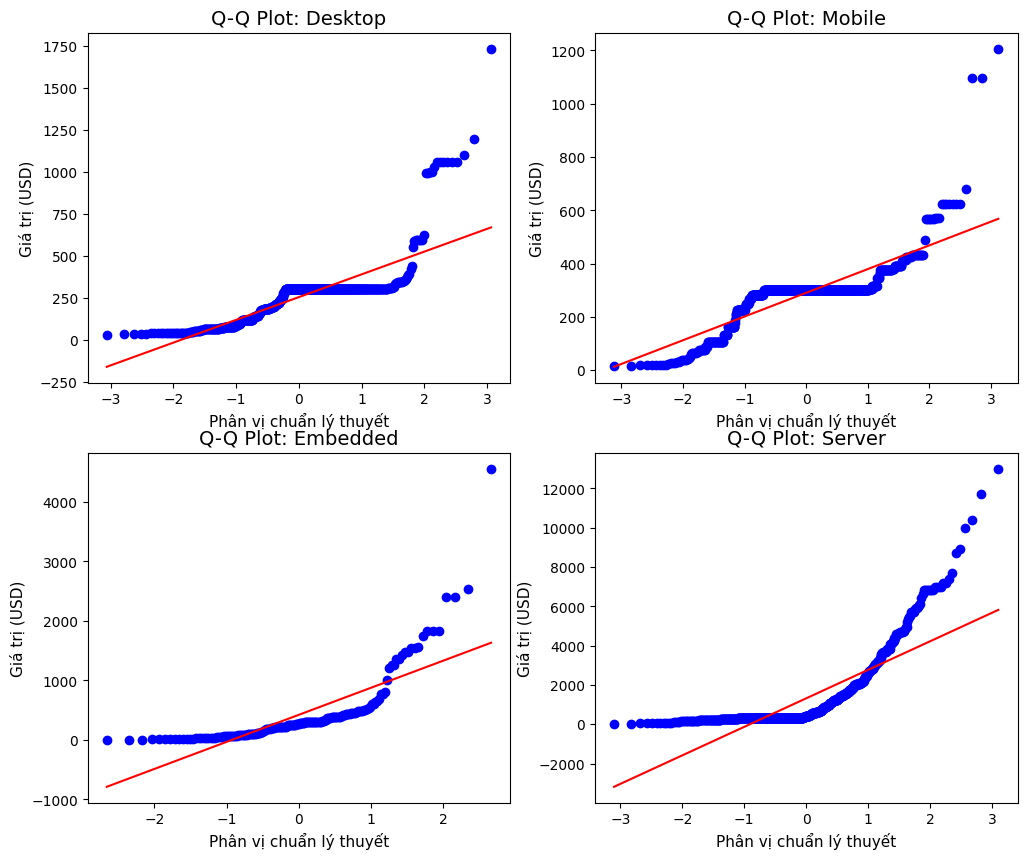

In [8]:
groups = [
    ('Desktop', desktop), 
    ('Mobile', mobile), 
    ('Embedded', embedded), 
    ('Server', server)
]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, data) in enumerate(groups):
    stats.probplot(data, dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {name}", fontsize=14)
    axes[i].set_xlabel("Phân vị chuẩn lý thuyết", fontsize=11)
    axes[i].set_ylabel("Giá trị (USD)", fontsize=11)
plt.show()

In [9]:
for name, data in groups:
    stat, p_val = stats.shapiro(data)
    print(f"Shapero-Wilk - {name: <10}: Statistic = {stat:.4f}, p-value = {p_val}")

Shapero-Wilk - Desktop   : Statistic = 0.6515, p-value = 7.725537204979993e-34
Shapero-Wilk - Mobile    : Statistic = 0.6898, p-value = 4.1722521196855565e-35
Shapero-Wilk - Embedded  : Statistic = 0.6231, p-value = 1.4704239395325332e-19
Shapero-Wilk - Server    : Statistic = 0.6621, p-value = 2.1665017277215353e-35


In [10]:
stat_lev, p_lev = stats.levene(desktop, mobile, embedded, server)

print(f"Levene- stat: {stat_lev:.4f} , p-value: {p_lev}")

Levene- stat: 156.5955 , p-value: 2.7973201758611196e-92
